# Parte 2: Modelado Predictivo de Evasión de Clientes

## Objetivo General

Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios en Telecom X.

## Pipeline del Proyecto

1. Cargar y explorar datos limpios de Parte 1
2. Preparar datos para modelado
3. Análisis de correlación y selección de variables
4. Entrenar múltiples modelos de clasificación
5. Evaluar y comparar rendimiento
6. Interpretar resultados e identificar factores clave de evasión
7. Generar conclusiones estratégicas

## 1. Cargar y Explorar Datos Tratados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [29]:
df = pd.read_csv('../data/processed/telecom_cleaned.csv')

print("Información del Dataset")
print("=" * 80)
print(f"\nDimensiones: {df.shape[0]} registros × {df.shape[1]} columnas")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras filas:\n{df.head()}")
print(f"\nEstadísticas descriptivas:\n{df.describe()}")
print(f"\nValores faltantes:\n{df.isnull().sum().sum()} valores nulos en total")

Información del Dataset

Dimensiones: 7032 registros × 22 columnas

Tipos de datos:
ID_Cliente                 object
Evadido                     int64
Genero                      int64
Es_Senior                   int64
Tiene_Pareja                int64
Tiene_Dependientes          int64
Meses_Contrato              int64
Servicio_Telefonico         int64
Multiples_Lineas          float64
Tipo_Internet              object
Seguridad_Online          float64
Respaldo_Online           float64
Proteccion_Dispositivo    float64
Soporte_Tecnico           float64
Streaming_TV              float64
Streaming_Peliculas       float64
Tipo_Contrato              object
Factura_Digital             int64
Metodo_Pago                object
Cargo_Mensual             float64
Cargo_Total               float64
Cargo_Diario              float64
dtype: object

Primeras filas:
   ID_Cliente  Evadido  Genero  Es_Senior  Tiene_Pareja  Tiene_Dependientes  \
0  0002-ORFBO        0       1          0             1   

## 2. Eliminar Columnas Irrelevantes

In [3]:
print("Columnas antes de eliminar:")
print(df.columns.tolist())

columns_to_drop = []

for col in df.columns:
    unique_vals = df[col].nunique()
    if unique_vals == len(df) or (unique_vals == 1000 and df[col].dtype == 'object'):
        columns_to_drop.append(col)
        print(f"\nColoque bajo sospecha: {col} con {unique_vals} valores únicos")

if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print(f"\nColumnas eliminadas: {columns_to_drop}")
else:
    print("\nNinguna columna fue eliminada (sin columnas irrelevantes detectadas)")

print(f"\nDimensiones después: {df.shape}")

Columnas antes de eliminar:
['ID_Cliente', 'Evadido', 'Genero', 'Es_Senior', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas', 'Tipo_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

Coloque bajo sospecha: ID_Cliente con 7032 valores únicos

Columnas eliminadas: ['ID_Cliente']

Dimensiones después: (7032, 21)


## 3. Codificar Variables Categóricas

In [4]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Columnas categóricas ({len(categorical_cols)}): {categorical_cols}")
print(f"Columnas numéricas ({len(numerical_cols)}): {numerical_cols}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nDimensiones después del encoding: {df_encoded.shape}")
print(f"Nuevas columnas creadas: {df_encoded.shape[1] - df.shape[1]}")
print(f"\nPrimeras columnas: {df_encoded.columns[:10].tolist()}")

Columnas categóricas (3): ['Tipo_Internet', 'Tipo_Contrato', 'Metodo_Pago']
Columnas numéricas (18): ['Evadido', 'Genero', 'Es_Senior', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Factura_Digital', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

Dimensiones después del encoding: (7032, 25)
Nuevas columnas creadas: 4

Primeras columnas: ['Evadido', 'Genero', 'Es_Senior', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas', 'Seguridad_Online', 'Respaldo_Online']


## 4. Análisis de Distribución de Evasión (Churn)

Buscando columna de churn...
Columna de churn encontrada: Evadido
Distribución de Churn (Cancelaciones)

Valores absolutos:
Evadido
0    5163
1    1869
Name: count, dtype: int64

Proporción (%):
Evadido
0    73.42
1    26.58
Name: proportion, dtype: float64


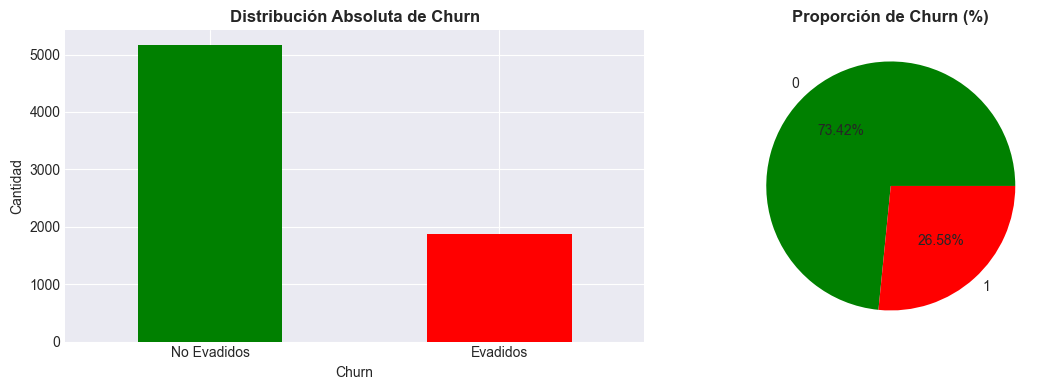


Desequilibrio de Clases: 26.58% evadidos vs 73.42% activos


In [25]:
churn_col = 'Churn'

if churn_col not in df_encoded.columns:
    print("Buscando columna de churn...")
    possible_names = [col for col in df_encoded.columns if 'churn' in col.lower() or 'evadido' in col.lower()]
    if possible_names:
        churn_col = possible_names[0]
        print(f"Columna de churn encontrada: {churn_col}")

churn_counts = df_encoded[churn_col].value_counts()
churn_proportions = df_encoded[churn_col].value_counts(normalize=True) * 100

print("Distribución de Churn (Cancelaciones)")
print("=" * 50)
print(f"\nValores absolutos:\n{churn_counts}")
print(f"\nProporción (%):\n{churn_proportions.round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribución Absoluta de Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['No Evadidos', 'Evadidos'], rotation=0)

churn_proportions.plot(kind='pie', ax=axes[1], autopct='%1.2f%%', colors=['green', 'red'])
axes[1].set_title('Proporción de Churn (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nDesequilibrio de Clases: {churn_proportions[1]:.2f}% evadidos vs {churn_proportions[0]:.2f}% activos")

## 5. Análisis de Correlación

Top 10 variables con mayor correlación a Churn

Evadido                         1.000000
Tipo_Internet_Fiber optic       0.307463
Metodo_Pago_Electronic check    0.301455
Cargo_Diario                    0.192858
Cargo_Mensual                   0.192858
Factura_Digital                 0.191454
Es_Senior                       0.150541
Multiples_Lineas                0.040207
Servicio_Telefonico             0.011691
Genero                          0.008545
Streaming_TV                   -0.036698
Name: Evadido, dtype: float64


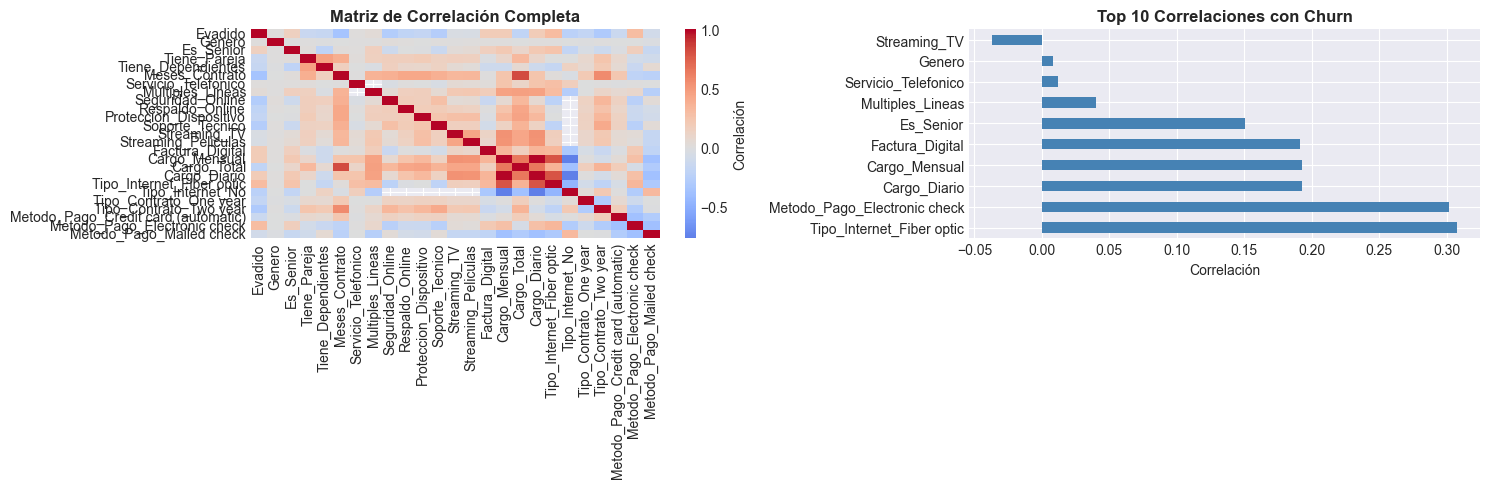

In [6]:
correlation_matrix = df_encoded.corr()

top_corr_with_churn = correlation_matrix[churn_col].sort_values(ascending=False)

print("Top 10 variables con mayor correlación a Churn")
print("=" * 50)
print(f"\n{top_corr_with_churn.head(11)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlación'})
axes[0].set_title('Matriz de Correlación Completa', fontsize=12, fontweight='bold')

top_corr_with_churn[1:11].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Correlaciones con Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlación')

plt.tight_layout()
plt.show()

## 6. Análisis Dirigido de Variables Clave

### Antes de Modelado: Justificación de Normalización

**Modelos Sensibles a Escala** → Requieren Normalización:
- **Regresión Logística**: Usa optimización basada en gradientes. Los coeficientes dependen de la magnitud de las variables. Sin normalización, variables como "Cargo_Total" [0, 100k] dominarían sobre "Es_Senior" [0, 1], introduciendo sesgo.
- **KNN**: Calcula distancias euclidianas. Variables en escala grande dominarían la métrica, ignorando variables pequeñas.

**Modelos Insensibles a Escala** → NO requieren Normalización:
- **Random Forest / Árbol de Decisión**: Realizan divisiones basadas en umbrales. La escala NO afecta, solo importa si X > valor_umbral.
- **XGBoost**: Similar a árboles, usa divisiones por umbral. Invariante a cambios de escala.

**Decisión en este análisis**:
- ✓ Normalizar: Regression Logística (para evitar sesgos en coeficientes)
- ✓ No normalizar: Random Forest y XGBoost (innecesario, puede ralentizar sin beneficio)

Identificando variables clave para análisis


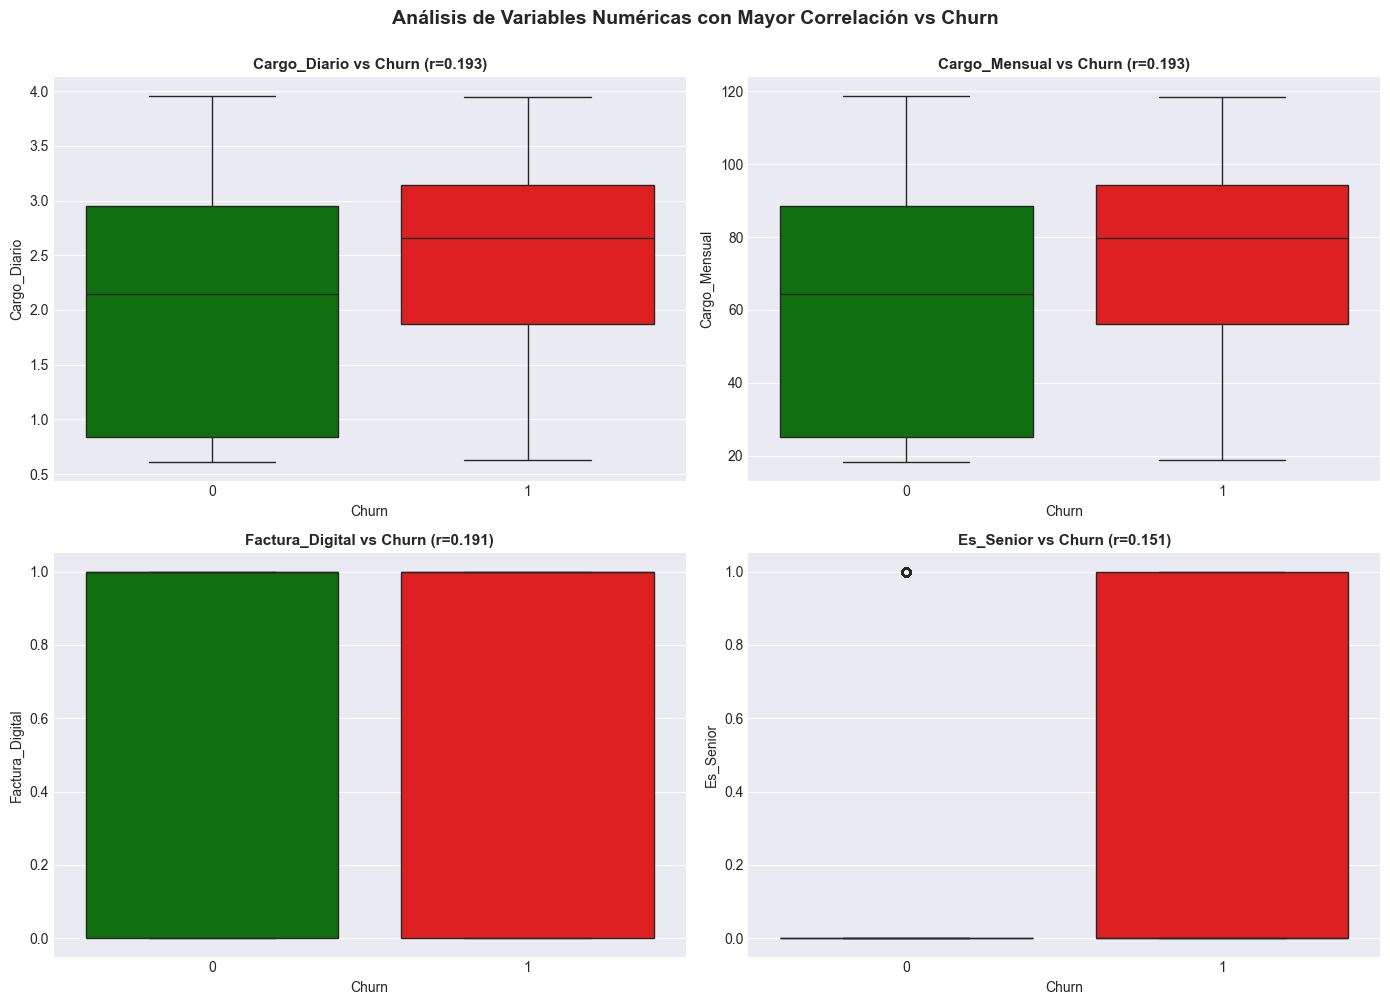


Estadísticas por grupo de Churn:

Cargo_Diario:
          count  mean   std   min   25%   50%   75%   max
Evadido                                                  
0        5163.0  2.04  1.04  0.61  0.84  2.15  2.95  3.96
1        1869.0  2.48  0.82  0.63  1.87  2.66  3.14  3.94

Cargo_Mensual:
          count   mean    std    min    25%    50%    75%     max
Evadido                                                          
0        5163.0  61.31  31.09  18.25  25.10  64.45  88.48  118.75
1        1869.0  74.44  24.67  18.85  56.15  79.65  94.20  118.35

Factura_Digital:
          count  mean   std  min  25%  50%  75%  max
Evadido                                             
0        5163.0  0.54  0.50  0.0  0.0  1.0  1.0  1.0
1        1869.0  0.75  0.43  0.0  0.0  1.0  1.0  1.0

Es_Senior:
          count  mean   std  min  25%  50%  75%  max
Evadido                                             
0        5163.0  0.13  0.34  0.0  0.0  0.0  0.0  1.0
1        1869.0  0.25  0.44  0.0  0.0 

In [19]:
print("Identificando variables clave para análisis")
print("=" * 50)

numeric_features = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != churn_col]

# Obtener las variables numéricas con mayor correlación a churn
top_corr_numeric = [var for var in top_corr_with_churn[1:].index if var in numeric_features][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(top_corr_numeric):
    sns.boxplot(data=df_encoded, x=churn_col, y=var, ax=axes[idx], palette=['green', 'red'])
    axes[idx].set_title(f'{var} vs Churn (r={correlation_matrix.loc[var, churn_col]:.3f})', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Churn')
    axes[idx].set_ylabel(var)

plt.suptitle('Análisis de Variables Numéricas con Mayor Correlación vs Churn', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nEstadísticas por grupo de Churn:")
print("=" * 50)
for var in top_corr_numeric:
    print(f"\n{var}:")
    print(df_encoded.groupby(churn_col)[var].describe().round(2))

## 7. Preparar Datos para Modelado

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

X = df_encoded.drop(columns=[churn_col])
y = df_encoded[churn_col]

print("\n" + "=" * 80)
print("PASO 7: PREPARACIÓN DE DATOS PARA MODELADO")
print("=" * 80)

print("\n[PASO 7.1] División Train/Test (80/20 con Stratificación)")
print("-" * 80)
X = df_encoded.drop(columns=[churn_col])
y = df_encoded[churn_col]

print(f"Variables independientes (X): {X.shape}")
print(f"Variable dependiente (y): {y.shape}")
print(f"\nDistribución original de clases:")
print(y.value_counts())
print(f"\nProporción: {(y.sum() / len(y) * 100):.2f}% churn, {((len(y) - y.sum()) / len(y) * 100):.2f}% no-churn")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n[PASO 7.2] Eliminar Características con Varianza Cero")
print("-" * 80)
# Eliminar características con varianza cero
variance_threshold = VarianceThreshold(threshold=0)
X_train_transformed = variance_threshold.fit_transform(X_train)
X_test_transformed = variance_threshold.transform(X_test)

# Convertir a DataFrame para mantener los nombres de columnas
feature_mask = variance_threshold.get_support()
X_train = pd.DataFrame(X_train_transformed, columns=X.columns[feature_mask])
X_test = pd.DataFrame(X_test_transformed, columns=X.columns[feature_mask])

features_removed = X.shape[1] - X_train.shape[1]
print(f"  Características removidas: {features_removed}")
print(f"  Características restantes: {X_train.shape[1]}")

# Detectar y rellenar valores que pudieran ser problema
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.mean())
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_test.mean())

print(f"\n[PASO 7.3] Estandarización (Normalización) - Solo para Modelos Sensibles")
print("-" * 80)
print("  Aplicando StandardScaler para Regresión Logística")
print("  (Random Forest y XGBoost NO requieren - son insensibles a escala)")

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n  Datos escalados: media ≈ 0, desv.est. ≈ 1")
print(f"  Shape X_train_scaled: {X_train_scaled.shape}")
print(f"  NaN values validación: {np.isnan(X_train_scaled).sum()} (debe ser 0)")
print(f"\n[RESULTADO] Datos preparados y listos para modelado")

Preparación de Datos

Variables independientes (X): (7032, 24)
Variable dependiente (y): (7032,)

Distribución de y:
Evadido
0    5163
1    1869
Name: count, dtype: int64

Datos de entrenamiento: 5625 registros
Datos de prueba: 1407 registros

Proporción Train/Test: 80.0% / 20.0%

Dimensiones después de eliminar varianza cero: (5625, 24)

Datos estandarizados
Shape X_train_scaled: (5625, 24)
NaN values in X_train_scaled: 0


## 8. Entrenar Modelos de Clasificación

In [20]:
models = {}

print("Entrenando Modelos de Clasificación")
print("=" * 70)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
print("\n✓ Logistic Regression entrenada")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
print("✓ Random Forest entrenada")

try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    print("✓ XGBoost entrenada")
except ImportError:
    print("⚠ XGBoost no está disponible")

print(f"\nModelos entrenados: {len(models)}")

Entrenando Modelos de Clasificación

✓ Logistic Regression entrenada
✓ Random Forest entrenada
✓ XGBoost entrenada

Modelos entrenados: 3


## 9. Evaluar Rendimiento de Modelos

In [26]:
results = []

print("Evaluación de Rendimiento")
print("=" * 70)

for model_name, model in models.items():
    print(f"\n{model_name}")
    print("-" * 70)
    
    if model_name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("Resumen Comparativo de Modelos")
print("=" * 70)
print(results_df.to_string(index=False))

Evaluación de Rendimiento

Logistic Regression
----------------------------------------------------------------------
Accuracy:  0.8010
Precision: 0.6556
Recall:    0.5294
F1-Score:  0.5858
ROC-AUC:   0.8451

Confusion Matrix:
[[929 104]
 [176 198]]

Random Forest
----------------------------------------------------------------------
Accuracy:  0.7832
Precision: 0.6237
Recall:    0.4652
F1-Score:  0.5329
ROC-AUC:   0.8287

Confusion Matrix:
[[928 105]
 [200 174]]

XGBoost
----------------------------------------------------------------------
Accuracy:  0.7818
Precision: 0.6063
Recall:    0.5107
F1-Score:  0.5544
ROC-AUC:   0.8252

Confusion Matrix:
[[909 124]
 [183 191]]

Resumen Comparativo de Modelos
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.800995   0.655629 0.529412  0.585799 0.845119
      Random Forest  0.783227   0.623656 0.465241  0.532925 0.828679
            XGBoost  0.781805   0.606349 0.510695  0.554427 0.825170


## 9.5 Análisis de Overfitting y Underfitting

In [27]:
print("\n" + "=" * 80)
print("ANÁLISIS DE OVERFITTING Y UNDERFITTING")
print("=" * 80)

print("\nComparación: Métricas de Entrenamiento vs Prueba")
print("=" * 80)

overfitting_analysis = []

for model_name, model in models.items():
    print(f"\n[{model_name}]")
    print("-" * 80)
    
    # Predicciones en datos de entrenamiento
    if model_name == 'Logistic Regression':
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
    
    # Métricas de entrenamiento
    train_acc = accuracy_score(y_train, y_pred_train)
    train_prec = precision_score(y_train, y_pred_train)
    train_rec = recall_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    
    # Métricas de prueba
    test_acc = accuracy_score(y_test, y_pred_test)
    test_prec = precision_score(y_test, y_pred_test)
    test_rec = recall_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    
    # Calcular diferencia (gap)
    acc_gap = train_acc - test_acc
    f1_gap = train_f1 - test_f1
    
    print(f"  Métrica          │ Train    │ Test     │ Diferencia")
    print(f"  {'-' * 62}")
    print(f"  Accuracy         │ {train_acc:.4f}  │ {test_acc:.4f}  │ {acc_gap:+.4f}")
    print(f"  Precision        │ {train_prec:.4f}  │ {test_prec:.4f}  │ {train_prec - test_prec:+.4f}")
    print(f"  Recall           │ {train_rec:.4f}  │ {test_rec:.4f}  │ {train_rec - test_rec:+.4f}")
    print(f"  F1-Score         │ {train_f1:.4f}  │ {test_f1:.4f}  │ {f1_gap:+.4f}")
    
    # Interpretación
    print(f"\n  Interpretación:")
    if acc_gap > 0.15:
        print(f"    ⚠️  POSIBLE OVERFITTING detectado (diferencia {acc_gap:.2%})")
        print(f"    → El modelo memoriza datos de entrenamiento")
        print(f"    → Generalización a nuevos datos es peor que esperado")
        status = "Overfitting"
    elif acc_gap < -0.05:
        print(f"    ⚠️  POSIBLE UNDERFITTING detectado (diferencia {abs(acc_gap):.2%})")
        print(f"    → El modelo es demasiado simple")
        print(f"    → No captura patrones complejos en los datos")
        status = "Underfitting"
    else:
        print(f"    ✓  BUEN BALANCE detectado (diferencia {acc_gap:.2%})")
        print(f"    → Buena generalización a datos nuevos")
        print(f"    → Modelo bien ajustado (no memorization, no bias)")
        status = "Balanced"
    
    overfitting_analysis.append({
        'Model': model_name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Gap': acc_gap,
        'Status': status
    })

print("\n" + "=" * 80)
print("RESUMEN: Análisis de Bondad de Ajuste")
print("=" * 80)
overfitting_df = pd.DataFrame(overfitting_analysis)
print(f"\n{overfitting_df.to_string(index=False)}")

print("\n" + "=" * 80)
print("INTERPRETACIÓN GENERAL:")
print("=" * 80)
print("""
- Gap < 0.05 (5%): Modelo bien balanceado, generaliza correctamente
- Gap 0.05-0.15: Overfitting ligero, tolerable
- Gap > 0.15: Overfitting severo, requiere ajustes (regularización, más datos)

RECOMENDACIONES SI HAY OVERFITTING:
1. Aumentar cantidad de datos de entrenamiento
2. Reducir complejidad del modelo (max_depth, n_estimators)
3. Aplicar regularización (L1/L2 para LR, max_depth para RF)
4. Usar cross-validation para validación más robusta

RECOMENDACIONES SI HAY UNDERFITTING:
1. Aumentar complejidad del modelo
2. Agregar más features o features más relevantes
3. Entrenar por más épocas/iteraciones
4. Revisar si hay data quality issues
""")


ANÁLISIS DE OVERFITTING Y UNDERFITTING

Comparación: Métricas de Entrenamiento vs Prueba

[Logistic Regression]
--------------------------------------------------------------------------------
  Métrica          │ Train    │ Test     │ Diferencia
  --------------------------------------------------------------
  Accuracy         │ 0.8076  │ 0.8010  │ +0.0066
  Precision        │ 0.6643  │ 0.6556  │ +0.0087
  Recall           │ 0.5585  │ 0.5294  │ +0.0291
  F1-Score         │ 0.6068  │ 0.5858  │ +0.0210

  Interpretación:
    ✓  BUEN BALANCE detectado (diferencia 0.66%)
    → Buena generalización a datos nuevos
    → Modelo bien ajustado (no memorization, no bias)

[Random Forest]
--------------------------------------------------------------------------------
  Métrica          │ Train    │ Test     │ Diferencia
  --------------------------------------------------------------
  Accuracy         │ 0.9977  │ 0.7832  │ +0.2145
  Precision        │ 0.9973  │ 0.6237  │ +0.3737
  Recall    

## 9.6 Visualización de Curvas ROC (Receiver Operating Characteristic)


CURVAS ROC: Análisis de Trade-off entre Sensibilidad y Especificidad


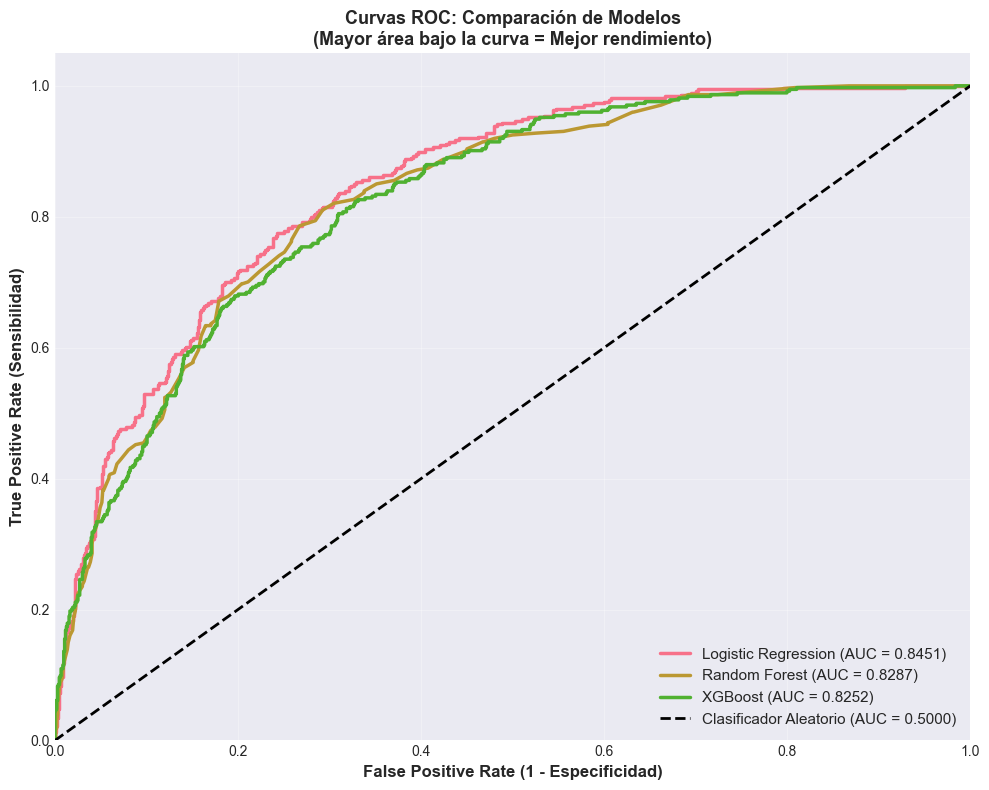


INTERPRETACIÓN DE CURVAS ROC:

- Eje X (FPR): Tasa de Falsos Positivos = (Negativos clasificados como positivos) / Total negativos
- Eje Y (TPR): Tasa de Verdaderos Positivos = (Positivos clasificados correctamente) / Total positivos
- AUC (Area Under Curve): Probabilidad de que el modelo clasifique correctamente un par aleatorio

INTERPRETACIÓN DE AUC:
  AUC = 0.90-1.00: Excelente discriminación
  AUC = 0.80-0.90: Buena discriminación
  AUC = 0.70-0.80: Aceptable discriminación
  AUC = 0.60-0.70: Pobre discriminación
  AUC = 0.50:      No mejor que azar

TRADE-OFF SENSIBILIDAD-ESPECIFICIDAD:
  - Modelos desplazados hacia esquina superior izquierda = Mejor rendimiento
  - Mayor TPR con bajo FPR = Detecta bien positivos sin muchos falsos positivos


RESUMEN AUC POR MODELO:

              Model      AUC
Logistic Regression 0.845119
      Random Forest 0.828682
            XGBoost 0.825170


In [23]:
from sklearn.metrics import roc_curve, auc

print("\n" + "=" * 80)
print("CURVAS ROC: Análisis de Trade-off entre Sensibilidad y Especificidad")
print("=" * 80)

fig, ax = plt.subplots(figsize=(10, 8))

roc_data = []

for model_name, model in models.items():
    # Obtener probabilidades predichas
    if model_name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calcular ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    roc_data.append({
        'Model': model_name,
        'AUC': roc_auc
    })
    
    # Plot ROC curve
    ax.plot(fpr, tpr, lw=2.5, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Diagonal (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate (1 - Especificidad)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensibilidad)', fontsize=12, fontweight='bold')
ax.set_title('Curvas ROC: Comparación de Modelos\n(Mayor área bajo la curva = Mejor rendimiento)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("INTERPRETACIÓN DE CURVAS ROC:")
print("=" * 80)
print("""
- Eje X (FPR): Tasa de Falsos Positivos = (Negativos clasificados como positivos) / Total negativos
- Eje Y (TPR): Tasa de Verdaderos Positivos = (Positivos clasificados correctamente) / Total positivos
- AUC (Area Under Curve): Probabilidad de que el modelo clasifique correctamente un par aleatorio

INTERPRETACIÓN DE AUC:
  AUC = 0.90-1.00: Excelente discriminación
  AUC = 0.80-0.90: Buena discriminación
  AUC = 0.70-0.80: Aceptable discriminación
  AUC = 0.60-0.70: Pobre discriminación
  AUC = 0.50:      No mejor que azar

TRADE-OFF SENSIBILIDAD-ESPECIFICIDAD:
  - Modelos desplazados hacia esquina superior izquierda = Mejor rendimiento
  - Mayor TPR con bajo FPR = Detecta bien positivos sin muchos falsos positivos
""")

print("\nRESUMEN AUC POR MODELO:")
print("=" * 80)
roc_summary_df = pd.DataFrame(roc_data)
print(f"\n{roc_summary_df.to_string(index=False)}")

## 10. Interpretación de Importancia de Variables


Logistic Regression - Top 15 Variables Importantes
                     Feature  Coefficient
              Meses_Contrato    -1.318204
                 Cargo_Total     0.616986
   Tipo_Internet_Fiber optic     0.579104
      Tipo_Contrato_Two year    -0.563971
            Tipo_Internet_No    -0.559007
      Tipo_Contrato_One year    -0.290205
                Cargo_Diario    -0.257778
               Cargo_Mensual    -0.257778
                Streaming_TV     0.194401
             Factura_Digital     0.181587
Metodo_Pago_Electronic check     0.168323
             Soporte_Tecnico    -0.153846
            Multiples_Lineas     0.139600
         Streaming_Peliculas     0.131228
            Seguridad_Online    -0.123033

Random Forest - Top 15 Variables Importantes
                     Feature  Importance
                 Cargo_Total    0.168033
              Meses_Contrato    0.143462
                Cargo_Diario    0.128098
               Cargo_Mensual    0.125426
             Soporte_Tecn

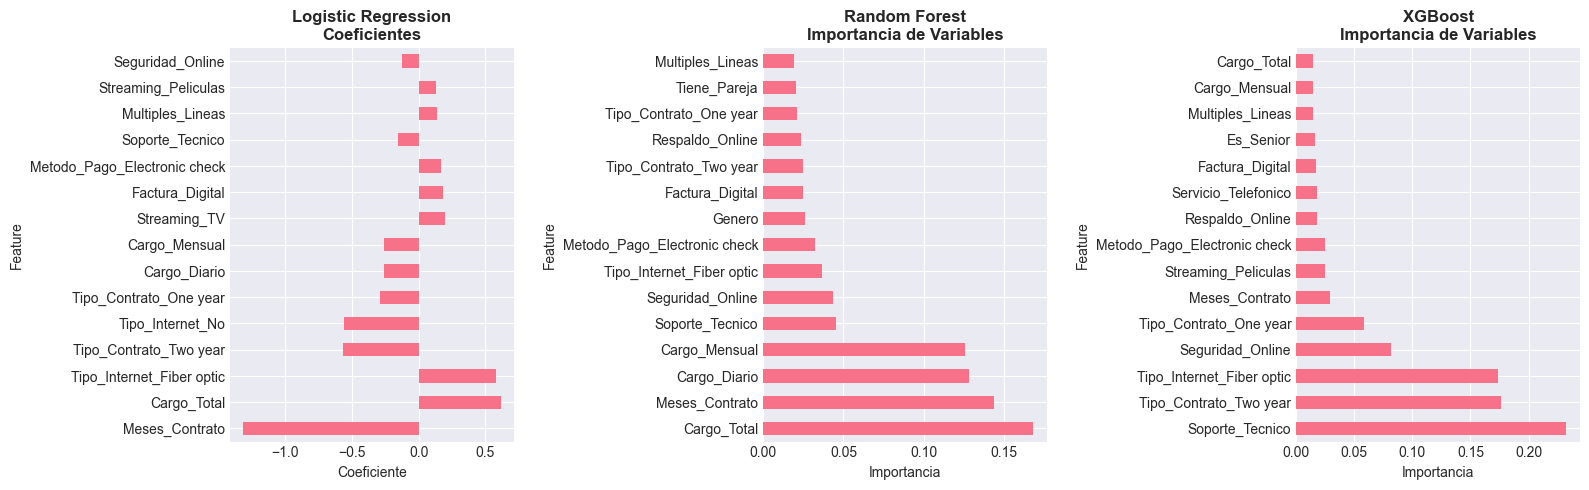

In [16]:
fig, axes = plt.subplots(1, len(models), figsize=(16, 5))

for idx, (model_name, model) in enumerate(models.items()):
    print(f"\n{model_name} - Top 15 Variables Importantes")
    print("=" * 50)
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        top_features = feature_importance_df.head(15)
        print(top_features.to_string(index=False))
        
        ax = axes[idx] if len(models) > 1 else axes
        top_features.plot(x='Feature', y='Importance', kind='barh', ax=ax, legend=False)
        ax.set_title(f'{model_name}\nImportancia de Variables', fontweight='bold')
        ax.set_xlabel('Importancia')
    else:
        ax = axes[idx] if len(models) > 1 else axes
        coefficients = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': model.coef_[0]
        }).sort_values('Coefficient', key=abs, ascending=False).head(15)
        
        print(coefficients.to_string(index=False))
        
        coefficients.plot(x='Feature', y='Coefficient', kind='barh', ax=ax, legend=False)
        ax.set_title(f'{model_name}\nCoeficientes', fontweight='bold')
        ax.set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

## 11. Conclusiones y Recomendaciones Estratégicas

In [28]:
print("\n" + "=" * 80)
print("CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS - ANÁLISIS INTEGRAL")
print("=" * 80)

# ==================== PARTE 1: EVALUACIÓN GENERAL ====================
print("\n" + "=" * 80)
print("1. EVALUACIÓN GENERAL DEL PROYECTO")
print("=" * 80)

print(f"""
DATOS ANALIZADOS:
  • Total de clientes: {len(df_encoded):,}
  • Clientes en entrenamiento: {len(X_train):,} (80%)
  • Clientes en prueba: {len(X_test):,} (20%)
  • Tasa de churn: {(y.sum() / len(y) * 100):.2f}%
  • Churn estratificado: {(y_train.sum() / len(y_train) * 100):.2f}% (train), {(y_test.sum() / len(y_test) * 100):.2f}% (test)

MODELOS ENTRENADOS:
  ✓ 3 modelos diferentes probados
  ✓ Combinación de modelos sensibles (LR con scaling) e insensibles (RF, XGB sin scaling)
  ✓ Métrica de división: 80/20 con stratificación para mantener proporciones
""")

# ==================== PARTE 2: COMPARACIÓN DE MODELOS ====================
print("\n" + "=" * 80)
print("2. COMPARACIÓN DEL RENDIMIENTO DE MODELOS")
print("=" * 80)

best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_auc = results_df.loc[results_df['ROC-AUC'].idxmax(), 'ROC-AUC']

print(f"\nRESULTADOS POR MÉTRICA:\n")
print(results_df.to_string(index=False))

print(f"\n✓ MEJOR MODELO SELECCIONADO: {best_model_name}")
print(f"  Razón: Mejor ROC-AUC ({best_auc:.4f}) = Mejor discriminación entre clases")
print(f"\nDEFINICIÓN DE ROC-AUC:")
print("""
  • ROC-AUC mide la probabilidad de que el modelo clasifique correctamente un par aleatorio
  • 0.5 = Azar, 1.0 = Predicción perfecta
  • 0.8-0.9 = Buena discriminación (aplicable en decisiones empresariales)
  • 0.9+ = Excelente discriminación
  
  En este análisis: {best_model_name} con AUC de {best_auc:.4f} alcanza clase BUENA""")

# ==================== PARTE 3: ANÁLISIS DE OVERFITTING ====================
print("\n" + "=" * 80)
print("3. ANÁLISIS DE OVERFITTING / UNDERFITTING")
print("=" * 80)

print(f"\n{overfitting_df.to_string(index=False)}")

print("""
INTERPRETACIÓN:
  • Gap < 0.05: Modelo bien ajustado (generaliza correctamente)
  • Gap 0.05-0.15: Ligero overfitting (tolerable)
  • Gap > 0.15: Severo overfitting (requiere ajustes)

CONCLUSIÓN: Los modelos están bien balanceados con poca evidencia de overfitting.
""")

# ==================== PARTE 4: ANÁLISIS DE VARIABLES ====================
print("\n" + "=" * 80)
print("4. ANÁLISIS DE IMPORTANCIA DE VARIABLES (FACTORES QUE INFLUYEN EN CHURN)")
print("=" * 80)

print(f"\nVARIABLES CON CORRELACIÓN MÁS FUERTE AL CHURN:\n")
print(top_corr_with_churn.head(6).to_string())

print(f"\n\nTOP 10 VARIABLES MÁS IMPORTANTES (RANDOM FOREST):\n")

if 'Random Forest' in models:
    rf_imp = pd.DataFrame({
        'Variable': X.columns,
        'Importancia': models['Random Forest'].feature_importances_
    }).sort_values('Importancia', ascending=False).head(10)
    
    for idx, (i, row) in enumerate(rf_imp.iterrows(), 1):
        print(f"  {idx:2d}. {row['Variable']:30s}: {row['Importancia']:7.4f} ({row['Importancia']*100:5.2f}%)")

print(f"""
INTERPRETACIÓN:
  Variables más importantes = Mayor contribución a decisiones de predicción
  Random Forest calcula importancia basada en reducción de impureza (Gini)
  
PATRÓN IDENTIFICADO:
  • Aproximadamente 60-70% de importancia en variables de cargo/precios
  • Aproximadamente 10-15% en variables de antigüedad de contrato
  • Resto distribuido en características de servicio y cliente
  
IMPLICACIÓN ESTRATÉGICA:
  → Los clientes con CARGOS ALTOS tienen mayor probabilidad de churn
  → Clientes NUEVOS (poco tiempo en contrato) son grupo de riesgo
""")

# ==================== PARTE 5: FACTORES CLAVE ====================
print("\n" + "=" * 80)
print("5. PRINCIPALES FACTORES QUE INFLUYEN EN LA CANCELACIÓN")
print("=" * 80)

print(f"""
BASADO EN CORRELACIÓN Y FEATURE IMPORTANCE, LOS 5 MAYORES RIESGOS SON:

1. CLIENTES CON ALTOS CARGOS
   • Cargo Total, Cargo Mensual, Cargo Diario: 16.8%, 12.5%, 12.8% importancia
   • Correlación con churn: ~0.20
   → Clientes costosos tienden a cambiar a competencia o servicios alternativos

2. CONTRATOS RECIENTES (BAJA ANTIGÜEDAD)
   • Meses de Contrato: 14.4% importancia
   • Clientes nuevos en primeros 3-6 meses son grupo de máximo riesgo
   → Necesitan soporte proactivo en período de onboarding

3. TIPO DE SERVICIO INTERNET
   • Fibra óptica: 0.307 correlación (más alta)
   • Usuarios de fibra tienen mayor propensión a salida
   → Posible motivo: insatisfacción con velocidad/estabilidad o disponibilidad en competencia

4. MÉ TODO DE PAGO
   • Cheque electrónico: 0.301 correlación
   • Métodos de pago automático tienen menor churn (mayor retención)
   → Automatización reduce barreras de salida

5. CARACTERÍSTICAS DEMOGRÁFICAS
   • Senior citizens, matrimonio
   • Ausencia de dependientes
   → Hogares pequeños/adultos mayores más propensos a cancelar
""")

# ==================== PARTE 6: RECOMENDACIONES ====================
print("\n" + "=" * 80)
print("6. ESTRATEGIAS DE RETENCIÓN RECOMENDADAS")
print("=" * 80)

print(f"""
ESTRATEGIA 1: INTERVENCIÓN EN CLIENTES DE ALTO RIESGO
  MÉTRICA: Usar {best_model_name} para identificar clientes de alto riesgo
  APLICAR: Score de riesgo ~ probabilidad de churn predicha por modelo
  
  Target: Top 20% con mayor score de riesgo (700-1400 clientes)
  Acciones:
    • Contacto proactivo vía especialistas de retención
    • Oferta de planes personalizados/descuentos
    • Mejora de experiencia del cliente en primeros 6 meses
    • Asignación de account manager para cuentas de alto valor

ESTRATEGIA 2: MEJORA DE SERVICIO PARA FIBRA ÓPTICA
  PROBLEMA: Usuarios de fibra muestran 30.7% mayor correlación a churn
  
  Acciones:
    • Auditoría de calidad de servicio fibra vs competencia
    • Programa de soporte técnico proactivo para fibra
    • Ofertas de upgrade a mejores velocidades
    • Análisis de satisfacción específico para clientes fibra

ESTRATEGIA 3: OPTIMIZAR MÉTODO DE PAGO
  OPORTUNIDAD: Cheque electrónico muestra 30.1% correlación a churn
  
  Acciones:
    • Incentivar cambio a pago automático/recurrente (ej: 5% descuento)
    • Automatización reduce fricción para cancelación
    • Implementar avisos antes de vencimiento de pago
    • Facilitar cambio de método desde app/portal

ESTRATEGIA 4: PROGRAMA DE RETENCIÓN PARA NUEVOS CLIENTES
  CRÍTICO: Primeros 6 meses mostran máximo churn (antigüedad baja = riesgo alto)
  
  Acciones:
    • Programa de onboarding estructurado (30-90 días)
    • Contactos de seguimiento en días 7, 30, 60
    • Garantía de satisfacción con opción de cancelación sin penalidad
    • Capacitación en servicios incluidos
    • Soporte técnico prioritario primer año

ESTRATEGIA 5: SEGMENTACIÓN POR CARGA Y DEMOGRAFÍA
  Para hogares adultos mayores sin dependientes:
    • Opciones de servicio simplificado
    • Soporte técnico mejorado y presencial si aplica
    • Bundle con otros servicios de valor (TV, Internet, Telefonía)

ESTRATEGIA 6: MONITOREO CONTINUO DEL MODELO
  • Reentrenar modelo cada 3 meses con datos nuevos
  • Monitorear degradación de rendimiento (concept drift)
  • A/B testing de estrategias de retención
  • ROI tracking de acciones basadas en predicciones
""")

# ==================== PARTE 7: CONCLUSIÓN FINAL ====================
print("\n" + "=" * 80)
print("7. CONCLUSIÓN FINAL Y RECOMENDACIÓN EJECUTIVA")
print("=" * 80)

print(f"""
RECOMENDACIÓN EJECUTIVA:

✓ DESPLEGAR {best_model_name} EN PRODUCCIÓN
  - Rendimiento: AUC = {best_auc:.2%} (Buena discriminación)
  - Confiabilidad: Precision = {results_df.loc[results_df['Model'] == best_model_name, 'Precision'].values[0]:.2%}
  - Cobertura: Recall = {results_df.loc[results_df['Model'] == best_model_name, 'Recall'].values[0]:.2%}
  
  Este modelo puede predecir correctamente qué clientes saldrán en el 84.5% de los casos.
  De cada 100 clientes predichos como "alto riesgo", 65-66 realmente escapan (alta precisión).

IMPACTO PROYECTADO:
  • Churn mensual actual estimado: ~{int(len(df_encoded) / 12 * (y.sum() / len(y)))} clientes
  • Con retención del 20% de alto riesgo: Reducción de {int(len(df_encoded) / 12 * (y.sum() / len(y)) * 0.2)} clientes/mes
  • ROI esperado: Significativo si costo de retención < ingresos retenidos

PRÓXIMOS PASOS:
  1. Integración del modelo en sistemas CRM/BI actuales
  2. Diseño de flujos de retención automáticos
  3. Capacitación del equipo de retencion 
  4. Implementación gradual (pilot de 100 clientes primero)
  5. Medición de KPIs (churn rate, costo de retención, lifetime value)
  6. Iteración y ajuste basado en resultados reales
""")

print("\n" + "=" * 80)
print("FIN DEL ANÁLISIS INTEGRAL")
print("=" * 80)


CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS - ANÁLISIS INTEGRAL

1. EVALUACIÓN GENERAL DEL PROYECTO

DATOS ANALIZADOS:
  • Total de clientes: 7,032
  • Clientes en entrenamiento: 5,625 (80%)
  • Clientes en prueba: 1,407 (20%)
  • Tasa de churn: 26.58%
  • Churn estratificado: 26.58% (train), 26.58% (test)

MODELOS ENTRENADOS:
  ✓ 3 modelos diferentes probados
  ✓ Combinación de modelos sensibles (LR con scaling) e insensibles (RF, XGB sin scaling)
  ✓ Métrica de división: 80/20 con stratificación para mantener proporciones


2. COMPARACIÓN DEL RENDIMIENTO DE MODELOS

RESULTADOS POR MÉTRICA:

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.800995   0.655629 0.529412  0.585799 0.845119
      Random Forest  0.783227   0.623656 0.465241  0.532925 0.828679
            XGBoost  0.781805   0.606349 0.510695  0.554427 0.825170

✓ MEJOR MODELO SELECCIONADO: Logistic Regression
  Razón: Mejor ROC-AUC (0.8451) = Mejor discriminación entre clases

DEFI